# Tomograf komputerowy - Raport

### 1. Skład grupy

Paweł Kociucki 160224
Piotr Rembeza 160176

### 2. Opis rozwiązania

W naszym rozwiązaniu zastosowaliśmy model stożkowy. Zaimplementowaliśmy go za pomocą języka Python oraz takich bibliotek jak: numpy (obliczenia), matplotlib (wizualizacja), datetime (pozyskanie daty), pydicom (obsługa plików DICOM), skimage (konwersja obrazu na bitmapę) oraz ipywidgets i IPython.display (suwaki). Dokładny opis najważniejszych funkcji znajduje się, dla przejrzystości,  w komentarzach kodu źródłowego.

In [29]:
import numpy as np
import matplotlib.pyplot as plt
import datetime
from skimage import io, color, draw
from pydicom.dataset import Dataset, FileDataset
import pydicom.uid
from pydicom.uid import ExplicitVRLittleEndian
import math
from skimage.util import img_as_ubyte
from skimage.exposure import rescale_intensity
import ipywidgets as widgets
from IPython.display import display

slider1 = widgets.FloatSlider(
    value=0.5,
    min=0.1,
    max=1,
    step=0.1,
    description='Krok:'
)
display(slider1)
krok=slider1.value
slider2 = widgets.IntSlider(
    value=250,
    min=100,
    max=500,
    step=10,
    description='Detektory:'
)
display(slider2)

detektory = slider2.value
slider3 = widgets.IntSlider(
    value=180,
    min=90,
    max=270,
    step=10,
    description='Rozpiętość kątowa:'
)
display(slider3)
rozpietosc_katowa = slider3.value
checkbox = widgets.Checkbox(
    value=False,
    description='Filtrowanie'
)

display(checkbox)
czy_filtr=checkbox.value
nazwaPliku = "dicom/SADDLE_PE.dcms"
nazwaPlikuJPG = "obrazy/CT_ScoutView.jpg"
patientData=dict()
patientData["PatientName"]="Jan Kowalski"
patientData["PatientID"]="1234"
patientData["ImageComments"]="Lorem Ipsum"

FloatSlider(value=0.5, description='Krok:', max=1.0, min=0.1)

IntSlider(value=250, description='Detektory:', max=500, min=100, step=10)

IntSlider(value=180, description='Rozpiętość kątowa:', max=270, min=90, step=10)

Checkbox(value=False, description='Filtrowanie')

In [35]:
#Przypisanie wartości suwaków do zmiennych
krok=slider1.value
detektory = slider2.value
rozpietosc_katowa = slider3.value
czy_filtr=checkbox.value
print("Krok: ", krok)
print("Detektory: ", detektory)
print("Rozpiętość kątowa: ", rozpietosc_katowa)
print("Filtrowanie: ", czy_filtr)

Krok:  1.0
Detektory:  280
Rozpiętość kątowa:  270
Filtrowanie:  True


In [36]:
def convert_image_to_ubyte(img): #konwersja obrazu do wersji 8-bitowej (znormalizowanej do przedziału [0,1])
    return img_as_ubyte(rescale_intensity(img, out_range=(0.0, 1.0)))
def save_as_dicom(file_name, img, patient_data): #Zapis do pliku DICOM
    img_converted = convert_image_to_ubyte(img)
    #=====Uzupełnienie metadanych pliku======
    file_meta = pydicom.Dataset() #stworzenie struktury przechowującej metadane
    file_meta.MediaStorageSOPClassUID = pydicom.uid.SecondaryCaptureImageStorage #typem danych jest SecondaryCapture (zwykły obraz)
    file_meta.MediaStorageSOPInstanceUID = pydicom.uid.generate_uid() #generacja unikalnego id pliku
    file_meta.ImplementationClassUID = pydicom.uid.generate_uid() #generacja unikalnego id implementacji
    file_meta.TransferSyntaxUID = pydicom.uid.ImplicitVRLittleEndian #format zapisu danych (Little Endian, zapis VR)
    ds = FileDataset(file_name, {}, file_meta=file_meta, preamble=b"\0" * 128) #stworzenie datasetu dla naszego pliku, dodatkowo przypisanie metadanych i preambuły
    #============Zapis podstawowych danych (daty, czasu, imienia i nazwiska pacjenta, jego ID i komentarz)=====
    now = datetime.datetime.now()
    ds.ContentDate = now.strftime('%Y%m%d')
    ds.ContentTime = now.strftime('%H%M%S')

    ds.PatientName = patient_data["PatientName"]
    ds.PatientID = patient_data["PatientID"]
    ds.ImageComments = patient_data["ImageComments"]
    #====Najważniejsze parametry dotyczące obrazu====
    ds.Rows, ds.Columns = img_converted.shape #wymiary obrazu
    ds.SamplesPerPixel = 1 #obraz monochromatyczny
    ds.PhotometricInterpretation = "MONOCHROME2" #sposób kodowania kolorów
    ds.PixelRepresentation = 0 #dane nieujemne (bez znaku)
    ds.HighBit = 7 #najwyższa możliwa wartość
    ds.BitsStored = 8 #liczba przechowywanych bitów na piksel
    ds.BitsAllocated = 8 #liczba bitów w pamięci

    #img = img.astype(np.uint16)
    #ds.PixelData = img.tobytes()



    #ds.save_as(file_name)
    #Sprawdzenie czy metadane spełniają standardy DICOM
    pydicom.dataset.validate_file_meta(ds.file_meta, enforce_standard=True)

    ds.PixelData = img_converted.tobytes() #zmiana obrazu na wersję bajtową

    ds.save_as(file_name, enforce_file_format=True) #zapis do pliku DICOM wymuszając zgodność z DICOM
def read_dicom_normalized(path): #czytanie pliku DICOM
    ds = pydicom.dcmread(path)
    image = ds.pixel_array.astype(np.float32)
    #=====Normalizacja=====
    min_val = np.min(image)
    max_val = np.max(image)
    if max_val > min_val:
        image_norm = (image - min_val) / (max_val - min_val)
    else:
        image_norm = np.zeros_like(image)
    return image_norm

In [37]:
#Obliczanie błędu średniokwadratowego
def blad_sredniokwadratowy(obraz_wej, obraz_wyj):
    obraz_wej = obraz_wej.astype(np.float64)
    obraz_wyj = obraz_wyj.astype(np.float64)
    #podstawienie pod wzór (średnia z kwadratów różnic na poszczególnych bajtach pomiędzy obrazem wejściowym i wyjściowym)
    return np.mean((obraz_wej - obraz_wyj) ** 2)
#Transformata Radona
def transformataRadona(obraz, krok, detektory, rozpietosc):
    #=====Deklaracja początkowych parametrów (wysokość i szerokość obrazu, promień okręgu opisanego, połowa wysokości i szerokości)
    h, w = obraz.shape[:2]
    r = 0.5 * np.sqrt(h**2 + w**2)
    cx = w / 2
    cy = h / 2

    theta = 0
    sinogram = []
    wynik=[]
    #pozyskanie odczytów (tak długo aż tomograf nie obróci się o 180 stopni)
    while theta <= 180:
        row = []
        theta_rad = np.radians(theta)

        # pozycja emitera
        Xe = cx + r * np.cos(theta_rad)
        Ye = cy + r * np.sin(theta_rad)

        start_angle = theta_rad + np.pi - np.radians(rozpietosc) / 2
        for i in range(detektory):
            alpha = start_angle + i * np.radians(rozpietosc) / (detektory - 1)

            # pozycja detektora
            Xd = cx + r * np.cos(alpha)
            Yd = cy + r * np.sin(alpha)

            # punkty na promieniu (algorytm Bresenhama)
            punkty = draw.line_nd((int(Ye), int(Xe)), (int(Yd), int(Xd)))
            #zapis odczytu do sinogramu dla każdego detektora
            suma = 0.0
            for k in range(len(punkty[0])):
                y = punkty[0][k]
                x = punkty[1][k]
                if 0 <= x < w and 0 <= y < h:
                    suma += obraz[y, x]  #sumujemy jasności
            row.append(suma)
        #zapis całego odczytu
        sinogram.append(row)
        wynik.append(np.array(sinogram))
        theta += krok
    return wynik

# ========================================================================================
try:
    image = read_dicom_normalized(nazwaPliku)
except:
    image = io.imread(nazwaPlikuJPG)
finally:
    if len(image.shape) == 3:
        image = color.rgb2gray(image)

sinogramy = transformataRadona(image, krok, detektory, rozpietosc_katowa)
for i in range(len(sinogramy)):
  sinogramy[i] /= np.max(sinogramy[i])


slider_sin = widgets.IntSlider(
    value=len(sinogramy),
    min=1,
    max=len(sinogramy),
    step=1,
    description='Etap:'
)
def pokaz_sin(pos):
  fig, ax = plt.subplots(1,2, figsize=(12,5))

  ax[0].imshow(image, cmap='gray')
  ax[0].set_title("Obraz wejściowy")
  ax[0].axis("off")
  ax[1].imshow(sinogramy[pos-1], cmap='gray', aspect='auto', extent=(0, 180, 0, sinogramy[pos-1].shape[0]))
  ax[1].set_title("Sinogram")
  ax[1].set_xlabel("Kąt (stopnie)")
  ax[1].set_ylabel("Pozycja detektora")
  plt.tight_layout()
  plt.show()
widgets.interact(pokaz_sin,pos=slider_sin)


interactive(children=(IntSlider(value=181, description='Etap:', max=181, min=1), Output()), _dom_classes=('wid…

<function __main__.pokaz_sin(pos)>

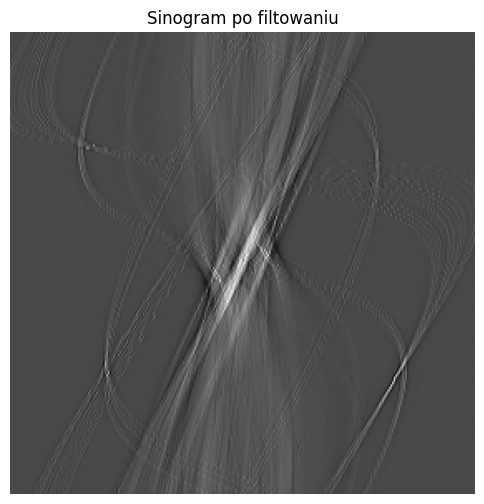

In [38]:
def kernel(n): #generacja filtra
    h = np.zeros(n)
    center = n // 2
    #====tworzenie filtra zgodnie z definicją
    for k in range(-center, center):
        if k == 0:
            h[center] = 1
        elif k % 2 != 0:
            h[center + k] = -4 / (np.pi**2 * k**2)
        else:
            h[center + k] = 0

    return h

def filtruj_sinogram(sinogram): #filtrowanie sinogramu
    filtr = kernel(21) #rozmiar maski - 21
    wynik = np.zeros_like(sinogram)
    #Dokonujemy splotu dla każdego wiersza sinogramu z naszym filtrem
    for i in range(sinogram.shape[0]):
        wynik[i] = np.convolve(sinogram[i], filtr, mode='same')

    return wynik
if czy_filtr==True:
  sinogramy[-1] = filtruj_sinogram(sinogramy[-1])
  plt.figure(figsize=(6,6))
  plt.imshow(sinogramy[-1], aspect='auto', cmap='gray', extent=(0, 180, 0, sinogramy[-1].shape[0]))
  plt.title("Sinogram po filtowaniu")
  plt.axis("off")
  plt.show()

Iteracja: 10 	MSE: 2664.9000931041137
Iteracja: 20 	MSE: 2664.329836154154
Iteracja: 30 	MSE: 2663.0482610353206
Iteracja: 40 	MSE: 2663.0023740299375
Iteracja: 50 	MSE: 2662.495210179474
Iteracja: 60 	MSE: 2661.662414201017
Iteracja: 70 	MSE: 2662.6282753725236
Iteracja: 80 	MSE: 2661.7811520283344
Iteracja: 90 	MSE: 2661.975923960097
Iteracja: 100 	MSE: 2661.294185063792
Iteracja: 110 	MSE: 2660.586994562226
Iteracja: 120 	MSE: 2659.9753090664562
Iteracja: 130 	MSE: 2660.2574624883623
Iteracja: 140 	MSE: 2660.3338825235414
Iteracja: 150 	MSE: 2660.0710697940544
Iteracja: 160 	MSE: 2659.810028543191
Iteracja: 170 	MSE: 2659.535841853659
Iteracja: 180 	MSE: 2659.2492371115645


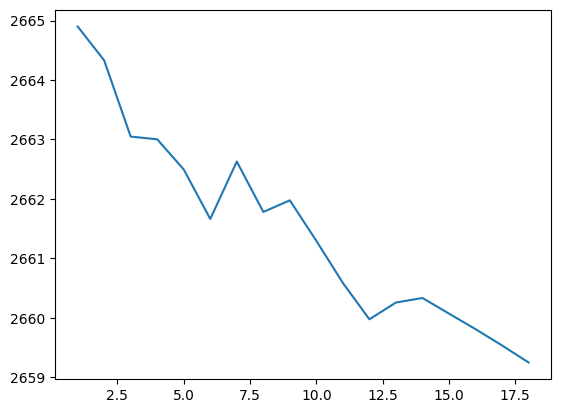

interactive(children=(IntSlider(value=182, description='Etap:', max=182, min=1), Output()), _dom_classes=('wid…

In [39]:
def odwrotnaTransformataRadona(sinogram, obraz_shape, krok, detektory, rozpietosc):
    #====Deklaracja zmiennych - analogicznie jak w transformacji Radona
    h, w = obraz_shape
    rekonstrukcje=[]
    rekonstrukcja = np.zeros((h, w))
    r = 0.5 * np.sqrt(h**2 + w**2)
    cx = w / 2
    cy = h / 2

    theta = 0
    j = 0
    rekonstrukcje.append(rekonstrukcja.copy())
    bledy=[]
    #odczyt z sinogramu i zapis do pustego obrazu
    #analogicznie jak dla zapisu do sinogramu
    while theta <= 180 and j < sinogram.shape[0]:
        theta_rad = np.radians(theta)

        # pozycja emitera
        Xe = cx + r * np.cos(theta_rad)
        Ye = cy + r * np.sin(theta_rad)
        start_angle = theta_rad + np.pi - np.radians(rozpietosc) / 2

        for i in range(detektory):
            #pozycja detektorów
            alpha = start_angle + i * np.radians(rozpietosc) / (detektory - 1)
            Xd = cx + r * np.cos(alpha)
            Yd = cy + r * np.sin(alpha)

            punkty = draw.line_nd((int(Ye), int(Xe)), (int(Yd), int(Xd)))
            wartosc = sinogram[j][i]
            #Zapis informacji z sinogramu do obrazu wynikowego
            for k in range(len(punkty[0])):
                y = punkty[0][k]
                x = punkty[1][k]
                if 0 <= x < w and 0 <= y < h:
                    rekonstrukcja[y, x] += wartosc
        rekonstrukcje.append(rekonstrukcja.copy())
        theta += krok
        j += 1
        #Obliczenie MSE dla co dziesiątego obrazu
        if j % 10 == 0:
            rek_norm = rekonstrukcja / np.max(rekonstrukcja)
            a=blad_sredniokwadratowy(image, rek_norm)
            print("Iteracja:", j, "\tMSE:", a)
            bledy.append(a)
    x=list(range(1,len(bledy)+1))
    plt.plot(x,bledy)
    plt.show()
    return rekonstrukcje

reconstructed = odwrotnaTransformataRadona(sinogramy[-1], image.shape, krok, detektory, rozpietosc_katowa)
slider = widgets.IntSlider(
    value=len(reconstructed),
    min=1,
    max=len(reconstructed),
    step=1,
    description='Etap:'
)
def pokaz(pos):
  plt.figure(figsize=(6,6))
  plt.imshow(reconstructed[pos-1], cmap='gray')
  plt.title("Rekonstrukcja (Back Projection)"+str(pos))
  plt.axis("off")
  plt.show()
widgets.interact(pokaz,pos=slider)
save_as_dicom("wyniki/wynik.dcm",reconstructed[-1],patientData)
